<a href="https://colab.research.google.com/github/inw1ze/SQL-study-project/blob/main/%D0%B1%D1%80%D0%B0%D0%B7%D0%B8%D0%BB%D1%8C%D1%81%D0%BA%D0%B8%D0%B9_%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%BF%D0%BB%D0%B5%D0%B9%D1%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [155]:
import os
print(os.listdir(path))

['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [203]:
file_path1 = os.path.join(path, 'olist_customers_dataset.csv')
file_path2 = os.path.join(path, 'olist_sellers_dataset.csv')
file_path3 = os.path.join(path, 'olist_order_reviews_dataset.csv')
file_path4 = os.path.join(path, 'olist_order_items_dataset.csv')
file_path5 = os.path.join(path, 'olist_products_dataset.csv')
file_path6 = os.path.join(path, 'olist_geolocation_dataset.csv')
file_path7 = os.path.join(path, 'product_category_name_translation.csv')
file_path8 = os.path.join(path, 'olist_orders_dataset.csv')
file_path9 = os.path.join(path, 'olist_order_payments_dataset.csv')
df_customer = pd.read_csv(file_path1, encoding = 'utf-8')
df_sellers = pd.read_csv(file_path2, encoding = 'utf-8')
df_order_det = pd.read_csv(file_path3, encoding = 'utf-8')
df_order_items = pd.read_csv(file_path4, encoding = 'utf-8')
df_product = pd.read_csv(file_path5, encoding = 'utf-8')
df_geol = pd.read_csv(file_path6, encoding = 'utf-8')
df_categor = pd.read_csv(file_path7, encoding = 'utf-8')
df_order_data = pd.read_csv(file_path8, encoding = 'utf-8')
df_order_pay = pd.read_csv(file_path9, encoding = 'utf-8')

In [157]:
df_merge = df_order_items.merge(df_product, on = 'product_id', how='inner')

In [158]:
top_product = df_merge.groupby(['product_id'])['price'].sum().reset_index()

Вывел топ 5 продуктов продаваемости за каждый месяц


In [159]:
top5_product = top_product.sort_values(['price'], ascending= False).head()

In [183]:
df_order_data1['Month'] = pd.to_datetime(df_order_data1['order_purchase_timestamp']).dt.strftime('%Y-%m')

/tmp/ipykernel_1263/2109877389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_order_data1['Month'] = pd.to_datetime(df_order_data1['order_purchase_timestamp']).dt.strftime('%Y-%m')


In [180]:
df_order_data1 = df_order_data[df_order_data['order_status'] == 'delivered']

In [185]:
df_order_data1 = df_order_data1.groupby(['Month'])['order_id'].count().reset_index()

In [187]:
df_order_data1 = df_order_data1[df_order_data1['Month'] >= '2017-01']

In [188]:
top_month['year'] = df_order_data1['Month'].apply(lambda x: x.split('-')[0])
top_month['mon'] = df_order_data1['Month'].apply(lambda x: x.split('-')[1])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '01'),
  Text(1, 0, '02'),
  Text(2, 0, '03'),
  Text(3, 0, '04'),
  Text(4, 0, '05'),
  Text(5, 0, '06'),
  Text(6, 0, '07'),
  Text(7, 0, '08'),
  Text(8, 0, '09'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12')])

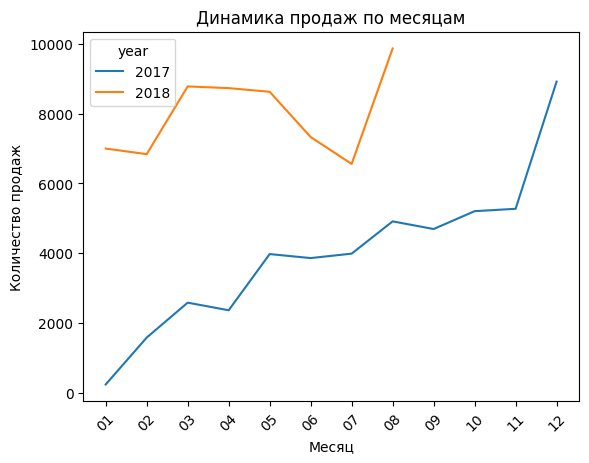

In [189]:
sns.lineplot(data = top_month, x = 'mon', y = 'order_id', hue = 'year')
#sns.barplot(data = top_month, x = 'Month', y = 'order_id')
plt.title('Динамика продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')
plt.xticks(rotation = 45)

In [190]:
df_order_pay.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [191]:
mrg_pay = df_order_data.merge(df_order_pay, on = 'order_id', how='inner')

In [192]:
mrg_pay['mon'] = pd.to_datetime(mrg_pay['order_purchase_timestamp']).dt.strftime('%Y-%m')

In [193]:
avg_pay = round(mrg_pay.groupby(['mon'])['payment_value'].mean().reset_index(), 2)

In [194]:
avg_pay['year'] = avg_pay['mon'].apply(lambda x: x.split('-')[0])
avg_pay['month'] = avg_pay['mon'].apply(lambda x: x.split('-')[1])

Text(0, 0.5, 'Сумма')

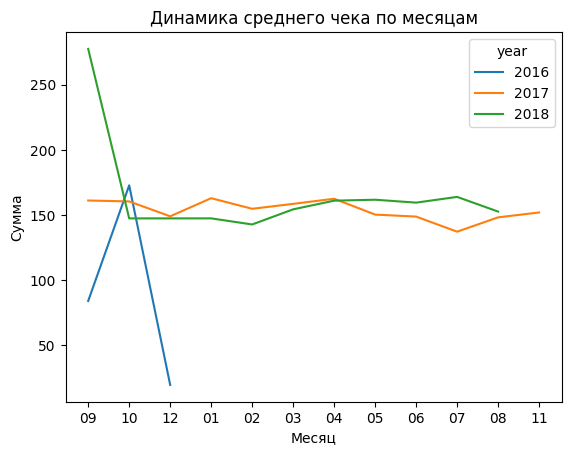

In [195]:
sns.lineplot(data = avg_pay, x = 'month', y = 'payment_value', hue = 'year')
plt.title('Динамика среднего чека по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [198]:
df_order_data.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [206]:
df_order_data31 = df_order_data[df_order_data['order_status'] == 'delivered']

In [208]:
df_order_data31.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0


In [214]:
df_customer.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [219]:
df_for_month = df_order_data[df_order_data['order_status'] == 'delivered']

In [221]:
df_for_city = df_for_month.merge(df_customer, on = 'customer_id',how = 'inner')

In [226]:
top5_city = df_for_city.groupby(['customer_city'])['order_id'].count().sort_values(ascending = False).reset_index().head()

Text(0, 0.5, 'Количество продаж')

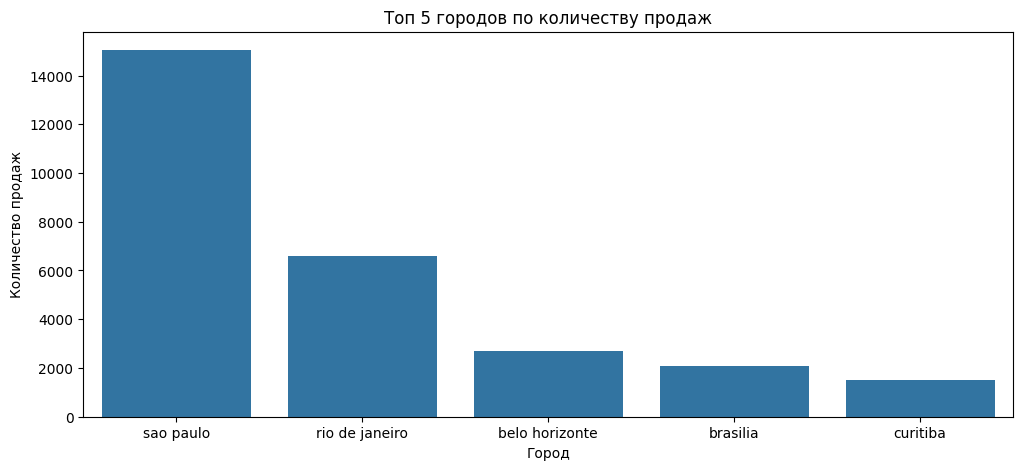

In [241]:
plt.figure(figsize = (12,5))
sns.barplot(data = top5_city, x = 'customer_city', y = 'order_id')
plt.title('Топ 5 городов по количеству продаж')
plt.xlabel('Город')
plt.ylabel('Количество продаж')

Text(0, 0.5, 'Количество продаж')

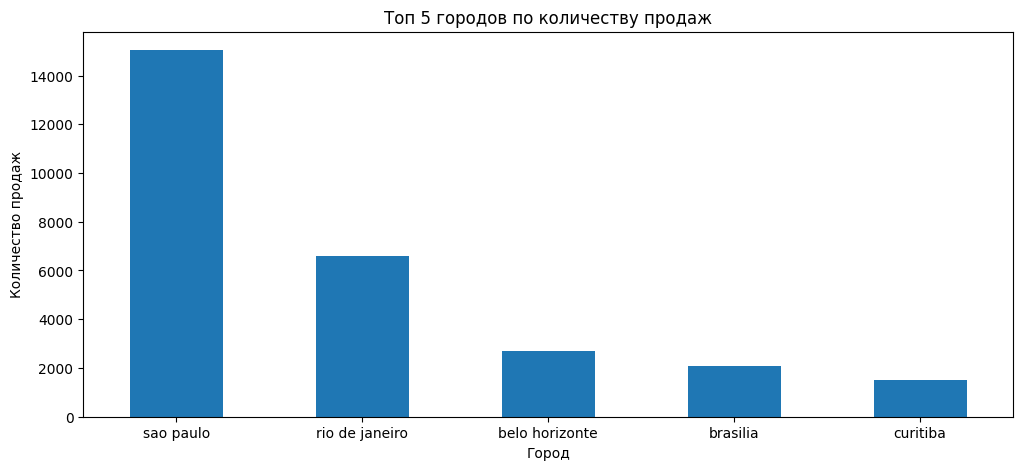

In [239]:
top5_city.plot(kind='bar', x = 'customer_city', y ='order_id',figsize=(12, 5), rot = 0, legend = False)
plt.title('Топ 5 городов по количеству продаж')
plt.xlabel('Город')
plt.ylabel('Количество продаж')